<div >
<img src = "../banner.jpg" />
</div>

<a target="_blank" href="https://colab.research.google.com/github/ignaciomsarmiento/BDML_202601/blob/main/Lecture15/01_PCA_Text_as_Data.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# Análisis de Componentes Principales (PCA)

Para ilustrar el uso de PCA, usamos el conjunto de datos del paper de Duflo, Dupas y Kremer (2011): ["Peer Effects, Teacher Incentives, and the Impact of Tracking: Evidence from a Randomized Evaluation in Kenya"](https://www.aeaweb.org/articles?id=10.1257/aer.101.5.1739)

**Abstract**

To the extent that students benefit from high-achieving peers, tracking will help strong students and hurt weak ones. However, all students may benefit if tracking allows teachers to better tailor their instruction level. Lower-achieving pupils are particularly likely to benefit from tracking when teachers have incentives to teach to the top of the distribution. We propose a simple model nesting these effects and test its implications in a randomized tracking experiment conducted with 121 primary schools in Kenya. While the direct effect of high-achieving peers is positive, tracking benefited lower-achieving pupils indirectly by allowing teachers to teach to their level. (JEL I21, J45, O15) 

In [1]:
require("pacman")
p_load("tidyverse","rio")

Loading required package: pacman



In [2]:
dta<-import("https://raw.githubusercontent.com/ignaciomsarmiento/datasets/refs/heads/main/duflo_data.csv")

In [3]:
summary(dta)

    pupilid           wordscore        sentscore       letterscore   
 Min.   : 4301003   Min.   : 0.000   Min.   : 0.000   Min.   : 0.00  
 1st Qu.: 6911061   1st Qu.: 0.000   1st Qu.: 0.000   1st Qu.: 6.00  
 Median : 7931574   Median : 2.000   Median : 2.000   Median :18.00  
 Mean   : 7817481   Mean   : 5.841   Mean   : 4.292   Mean   :22.21  
 3rd Qu.: 9381069   3rd Qu.:10.000   3rd Qu.: 6.000   3rd Qu.:35.00  
 Max.   :10201055   Max.   :24.000   Max.   :38.000   Max.   :70.00  
   spellscore     additions_score substractions_score multiplications_score
 Min.   : 0.000   Min.   :0.000   Min.   :0.000       Min.   :0.0000       
 1st Qu.: 0.000   1st Qu.:2.000   1st Qu.:1.000       1st Qu.:0.0000       
 Median : 0.000   Median :4.000   Median :3.000       Median :0.0000       
 Mean   : 2.241   Mean   :3.661   Mean   :3.134       Mean   :0.7632       
 3rd Qu.: 4.000   3rd Qu.:5.000   3rd Qu.:5.000       3rd Qu.:2.0000       
 Max.   :10.000   Max.   :9.000   Max.   :9.000       

En este paper se reportan puntajes en siete secciones de un examen (cuatro de lenguaje y tres de matemáticas).

Variables:

- pupilid        : ID of student
- wordscore      : Endline Score on Word Recognition section (max: 24)
- sentscore      : Endline Score on Sentence Recognition section (max: 40 )
- letterscore    : Endline Score on Letter Recognition section (max: 70)
- spellscore     : Endline Score on Spelling section (max: 10)
- additions_score: Endline Score on Additions section
- substractionscore: Endline Score on Substractions section
- multiplicationscore: Endline Score on Multiplications section


In [4]:
cor(dta[,2:8])

,wordscore,sentscore,letterscore,spellscore,additions_score,substractions_score,multiplications_score
wordscore,1.0000000,0.5510714,0.6230291,0.7983145,0.4887001,0.4085711,0.4131300
sentscore,0.5510714,1.0000000,0.4546188,0.5479455,0.3216864,0.2564428,0.2827520
letterscore,0.6230291,0.4546188,1.0000000,0.7081031,0.5319175,0.4765021,0.4285407
spellscore,0.7983145,0.5479455,0.7081031,1.0000000,0.5215661,0.4486892,0.4506957
additions_score,0.4887001,0.3216864,0.5319175,0.5215661,1.0000000,0.7039169,0.5141140
substractions_score,0.4085711,0.2564428,0.4765021,0.4486892,0.7039169,1.0000000,0.5009072
multiplications_score,0.4131300,0.2827520,0.4285407,0.4506957,0.5141140,0.5009072,1.0000000


In [5]:
# get rid of pupilid
dta<-dta[,2:8]

# PCA
res_pca <- prcomp(dta, scale=TRUE)
res_pca

Standard deviations (1, .., p=7):
[1] 2.0045568 1.0223246 0.7494389 0.7248582 0.6103161 0.5380344 0.4330818

Rotation (n x k) = (7 x 7):
                            PC1        PC2         PC3        PC4         PC5
wordscore             0.4104296  0.3221509 -0.08282838  0.2203340 -0.56406683
sentscore             0.3159957  0.4940686  0.32540508 -0.7198700  0.17848174
letterscore           0.4040097  0.1264519 -0.27597945  0.3276965  0.76658737
spellscore            0.4294850  0.2767611 -0.11471715  0.2813439 -0.20801712
additions_score       0.3848066 -0.4078762 -0.24164856 -0.2575322 -0.11920383
substractions_score   0.3548314 -0.5153544 -0.24847442 -0.3147293 -0.04656169
multiplications_score 0.3317100 -0.3571765  0.82328169  0.2851725  0.05165280
                               PC6          PC7
wordscore              0.058013773  0.592302045
sentscore              0.007690033 -0.005173901
letterscore           -0.014227263  0.222211132
spellscore             0.068974270 -0.773694307

In [6]:
p_load("factoextra")
eig_val <- get_eigenvalue(res_pca)
eig_val

,eigenvalue,variance.percent,cumulative.variance.percent
,<dbl>,<dbl>,<dbl>
Dim.1,4.0182478,57.403541,57.40354
Dim.2,1.0451476,14.930680,72.33422
Dim.3,0.5616586,8.023694,80.35791
Dim.4,0.5254194,7.505991,87.86391
Dim.5,0.3724858,5.321225,93.18513
Dim.6,0.2894810,4.135443,97.32057
Dim.7,0.1875598,2.679426,100.00000


In [7]:
sum(eig_val$eigenvalue)

[1] 7

Los autovalores suman 7 (una por cada variable). Por ejemplo:

* El **primer autovalor** es aproximadamente 4.0, lo que indica que la primera componente explica alrededor del **57% de la varianza** total.
* El **segundo autovalor** es cercano a 1.0, y explica un **15% adicional**.

En total, las **dos primeras componentes** explican el **72% de la varianza** en los siete puntajes.

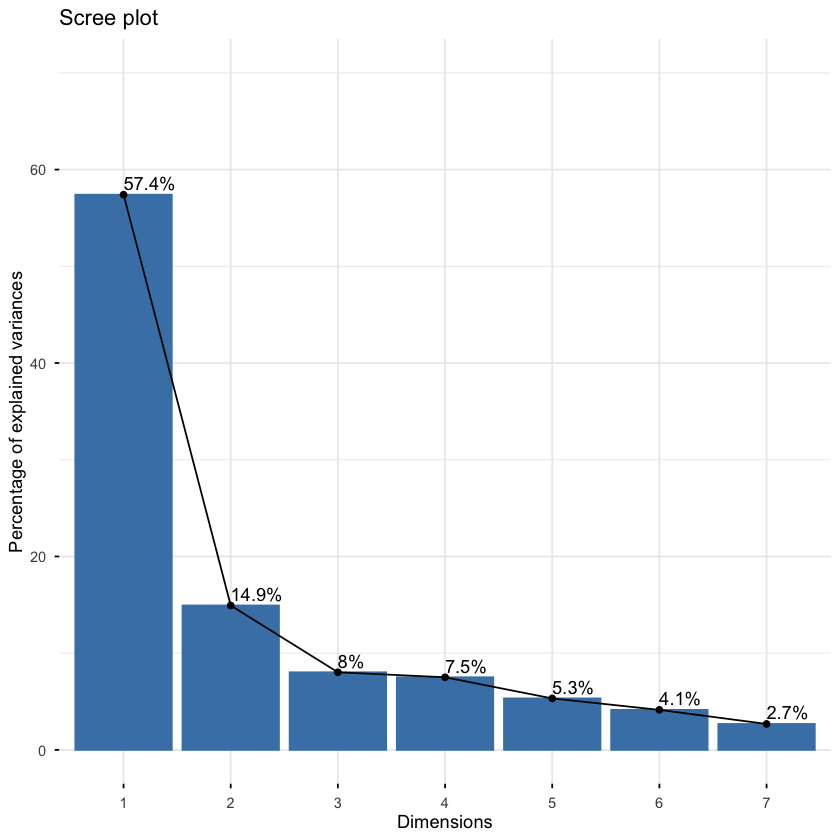

In [8]:
fviz_eig(res_pca, addlabels = TRUE, ylim = c(0, 70))

También podemos visualizar la varianza acumulada:

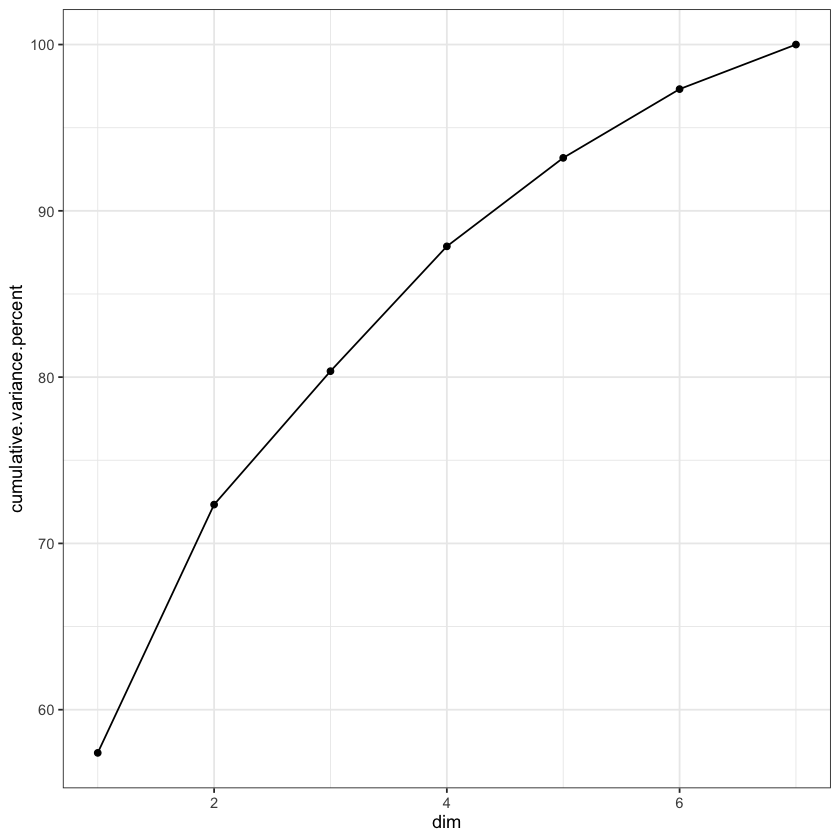

In [9]:
eig_val$dim<-seq(1:7)
ggplot(data=eig_val,aes(x=dim,y=cumulative.variance.percent)) +
    geom_point()+
    geom_line() +
    theme_bw()


## Interpretación de las componentes principales


In [ ]:
res_pca


En la **Tabla de vectores propios**  vemos los **pesos (cargas)** de cada variable sobre cada componente:

### PC1

Para la **primera componente**, todos los pesos son **positivos y similares**, lo que sugiere que esta componente es muy parecida a un **promedio simple** de los siete puntajes. Es decir, la primera componente captura la mayoria de la información contenida en los 7 puntajes y resume el rendimiento general del estudiante.

Que todos los pesos tengan un mismo signo (no importa cual es) nos dice que hay una dimensión común de rendimiento que domina la variabilidad en los datos. En lugar de tratar de interpretar siete puntajes distintos, podemos resumirlos de forma bastante precisa usando una sola variable: la primera componente principal.


### PC2

Para la **segunda componente**, los pesos tienen un patron diferente. Los **cuatro puntajes de lenguaje** tienen pesos positivos y los **tres de matemáticas**, negativos. 

Esta componente está capturando una contraposición o contraste entre dos grupos de variables.

Esto indica que esta componente representa algo como la **diferencia relativa entre habilidades matemáticas y verbales**.



Entonces 


* El **57% de la variación** en los puntajes puede explicarse por una sola variable resumen: el promedio general.
* El **72% de la variación** se puede explicar si consideramos además por separado los puntajes en matemáticas y lenguaje.

En otras palabras, con solo dos componentes principales capturamos casi tres cuartas partes de la información contenida en los siete puntajes individuales.

### Biplot

El biplot es una herramienta visual muy útil en el análisis de componentes principales, ya que permite observar en un mismo gráfico:

 * A los individuos (en este caso, los estudiantes) proyectados en el espacio de los primeros dos componentes principales.

 * A las variables originales (los siete puntajes del test), representadas como vectores.

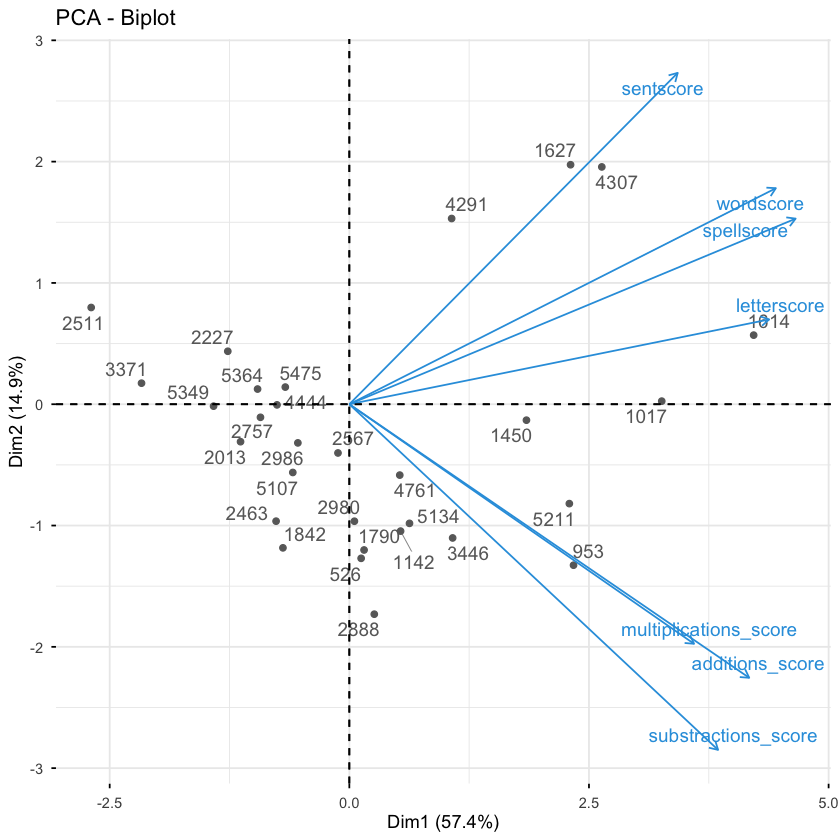

In [10]:
set.seed(123)  # Fijar semilla para reproducibilidad


# Seleccionar algunos individuos aleatoriamente (faster)
subset_ids <- sample(1:dim(dta)[1], 30)

fviz_pca_biplot(res_pca, 
                repel = TRUE,# Avoid text overlapping
                col.var = "#2E9FDF", # Variables color
                col.ind = "#696969", #"white" #  Individuals color
                select.ind = list(name = subset_ids)
                )

#### ¿Cómo se interpreta?

**1. Posición de los individuos (puntos grises):**
Cada punto representa a un estudiante. Estos son los "scores" o "puntajes principales" de los componentes. Son los valores proyectados sobre PC1 y PC2. Entonces su ubicación refleja su posición en las primeras dos componentes principales:

* Estudiantes que están cerca del centro tienen un rendimiento más promedio.
* Estudiantes alejados del centro tienen rendimientos más extremos (positivos o negativos).
* La dirección de su posición indica si destacan más en habilidades verbales o matemáticas.

Estudiantes que aparecen cerca del centro del biplot (el punto 0,0) no se desvían mucho del promedio del grupo, ni en el rendimiento general (captado por la primera componente), ni en la diferencia entre áreas (captada por la segunda componente). Es decir, tienen un perfil académico bastante "típico" o balanceado.

In [ ]:
dta[2567,]

In [ ]:
summary(dta)

In [ ]:
dta[953,]



**2. Dirección y longitud de las flechas (variables):**
Cada flecha representa una de las variables originales (los puntajes en secciones del test).

* **La dirección de la flecha** indica hacia dónde crece el valor de esa variable.
* **La longitud de la flecha** indica el peso de la variable en el componente

**3. Ángulo entre flechas:**

* Si dos flechas apuntan en la **misma dirección**, las variables están **positivamente correlacionadas**.
* Si forman un **ángulo de 90°**, las variables son **no correlacionadas**.
* Si apuntan en **direcciones opuestas**, están **negativamente correlacionadas**.

En nuestro caso

* Las flechas correspondientes a los **puntajes de lenguaje**  estén agrupadas y apunten en una dirección similar.
* Lo mismo ocurre con las de **matemáticas**, pero en dirección opuesta a las de lenguaje en la segunda componente.
* Esto refuerza la interpretación de la segunda componente como una especie de contraste entre habilidades matemáticas y verbales.



##  Votos en el congreso de Estados Unidos

Este es un ejemplo un poco mas complejo de como votan los miembros del Congreso de Estados Unidos. 

Tenemso información de los votos del 111vo Congreso que cubre los años 2009 y 2010, que son los dos primeros años de la presidencia de Obama.

Hay 445 miembros que votan en la casa de representantes (US House of Representatives) y se registraron 1647 votos con -1 por el negativo, +1 por positivo, y 0 por la abstencion o la ausencia

In [11]:
votes <- read.csv("https://github.com/ignaciomsarmiento/datasets/raw/main/rollcall-votes.csv")
head(votes)

,Vote.1,Vote.2,Vote.3,Vote.4,Vote.5,Vote.6,Vote.7,Vote.8,Vote.9,Vote.10,⋯,Vote.1638,Vote.1639,Vote.1640,Vote.1641,Vote.1642,Vote.1643,Vote.1644,Vote.1645,Vote.1646,Vote.1647
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
BONNER (R AL-1),-1,1,-1,0,0,1,-1,-1,1,1,⋯,-1,0,-1,-1,-1,-1,0,1,1,0
BRIGHT (D AL-2),1,-1,1,1,1,1,-1,-1,1,1,⋯,1,1,0,0,0,0,0,0,0,0
ROGERS (R AL-3),-1,1,-1,-1,-1,1,-1,-1,1,1,⋯,-1,-1,-1,-1,-1,1,-1,-1,1,1
ADERHOLT (R AL-4),-1,1,-1,-1,1,1,-1,-1,1,1,⋯,-1,-1,-1,-1,-1,-1,-1,-1,1,1
GRIFFITH (D/R AL-5),1,-1,1,1,1,-1,-1,-1,1,1,⋯,0,0,0,0,0,0,0,0,0,0
BACHUS (R AL-6),-1,1,-1,1,1,1,-1,0,1,1,⋯,-1,-1,-1,-1,-1,-1,-1,-1,1,-1


In [12]:
dim(votes)

[1]  445 1647

In [13]:
legis <- read.csv("https://github.com/ignaciomsarmiento/datasets/raw/main/rollcall-members.csv")
head(legis)

,member,state,party
,<chr>,<chr>,<chr>
1,BONNER (R AL-1),AL,R
2,BRIGHT (D AL-2),AL,D
3,ROGERS (R AL-3),AL,R
4,ADERHOLT (R AL-4),AL,R
5,GRIFFITH (D/R AL-5),AL,DR
6,BACHUS (R AL-6),AL,R


En este contexto podriamos pensar para una estructura factorial subjacente de baja dimensión. Aunque cada uno de los votos se refiere a temas diferentes, los representantes suelen están alineados según ejes partidistas e ideológicos (por ejemplo, republicano versus demócrata o liberal versus conservador). Si creemos que todos los votos son partidistas, entonces el voto por el miembro i en el tema j podría predecirse como

$$
x_{i} = h f_i
$$

donde f es el posicionamiento ideologico latente y h como este posicionamiento afecta los votos. Este tipo de situaciones es ideal para PCA

In [14]:
#Estimamos PCA
pcavote <- prcomp(votes, scale=TRUE)

pcavote$rotation

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC436,PC437,PC438,PC439,PC440,PC441,PC442,PC443,PC444,PC445
Vote.1,0.0392185821,-0.0052814541,-0.0008821592,-0.0117965967,0.0002234136,2.999469e-02,-1.090707e-03,-0.0026042631,-0.009523944,0.006486599,⋯,-0.0212793756,-0.0107902248,-0.0301143828,-0.020240273,-0.0069774850,-0.008754050,-0.0041422823,0.024651573,-0.043466380,0.909287636
Vote.2,-0.0391977117,0.0032592190,0.0008552094,0.0119564321,-0.0014956698,-2.882768e-02,7.597981e-04,0.0011994905,0.010585114,-0.009037791,⋯,0.0069393063,-0.0042546377,0.0132455132,0.019822224,-0.0115884166,-0.010676636,-0.0215602171,0.056161912,0.016055304,-0.029070823
Vote.3,0.0381410874,-0.0044353607,-0.0001600903,-0.0106797268,0.0034774543,3.353233e-02,1.066685e-05,-0.0069603353,-0.012714053,0.010662978,⋯,-0.0356690409,0.0002374927,0.0261320869,-0.007325811,0.0214683750,0.035740010,0.0036534767,-0.072064709,-0.036380009,0.016879411
Vote.4,0.0203992707,0.0082194904,-0.0280883389,0.0389080492,0.0183515726,-4.768084e-03,-2.677192e-03,0.0704461703,-0.001643367,-0.032532043,⋯,-0.0108651511,0.0343440430,-0.0521666257,-0.016195281,0.0077677227,0.001940784,0.0217344758,-0.025171122,0.015689614,-0.132363088
Vote.5,0.0147399686,0.0169888169,-0.0316774462,0.0515466564,-0.0340640434,1.020201e-03,2.167432e-02,0.0545236565,-0.020209752,-0.039871415,⋯,-0.0249034577,0.0095515528,0.0183592390,0.004744497,-0.0226384179,0.005184316,-0.0141080610,-0.021946415,0.020099933,0.027591092
Vote.6,-0.0383793547,0.0045961508,-0.0002815467,0.0166070856,0.0040331077,-8.138595e-03,-3.470207e-03,0.0077584251,0.003922493,-0.004970230,⋯,-0.0241409880,-0.0076464209,0.0032134638,-0.013894853,-0.0060208176,-0.024922080,-0.0412765022,0.029405692,-0.005844300,-0.155583740
Vote.7,0.0377997580,-0.0045300307,-0.0027346688,-0.0001670661,0.0096342291,1.590377e-02,-1.299722e-03,0.0056927282,0.009770811,0.006116563,⋯,-0.0098752146,-0.0155259383,-0.0149488764,-0.009285142,-0.0188701537,0.004363155,-0.0018068685,0.083311723,-0.045786254,-0.045498514
Vote.8,0.0380978333,-0.0058386593,-0.0008119522,-0.0104878232,0.0030469251,1.636814e-02,5.155197e-03,-0.0068556508,-0.009313019,0.001804481,⋯,-0.0028414330,-0.0070280371,0.0140515722,0.023684427,0.0041090795,-0.004897517,-0.0093436615,0.048934548,-0.031210393,-0.027962782
Vote.9,-0.0045462197,0.0222313274,-0.0250906383,0.0039177561,-0.0192115406,7.794234e-02,3.990486e-02,-0.0057765206,-0.008100532,-0.003125013,⋯,0.0504129746,-0.0142633078,0.0042573822,0.025273132,-0.0340559394,0.013050845,0.0022509701,-0.034213448,0.030537844,0.014246510
Vote.10,0.0020402433,0.0336133082,-0.0296609660,-0.0213705319,0.0267938017,7.128690e-03,5.273481e-02,0.0226609217,-0.023839753,-0.027991486,⋯,0.0236167142,0.0008553311,-0.0180307324,-0.011297842,-0.0091911928,0.022595819,0.0240169982,-0.064747505,0.010313724,-0.003027985


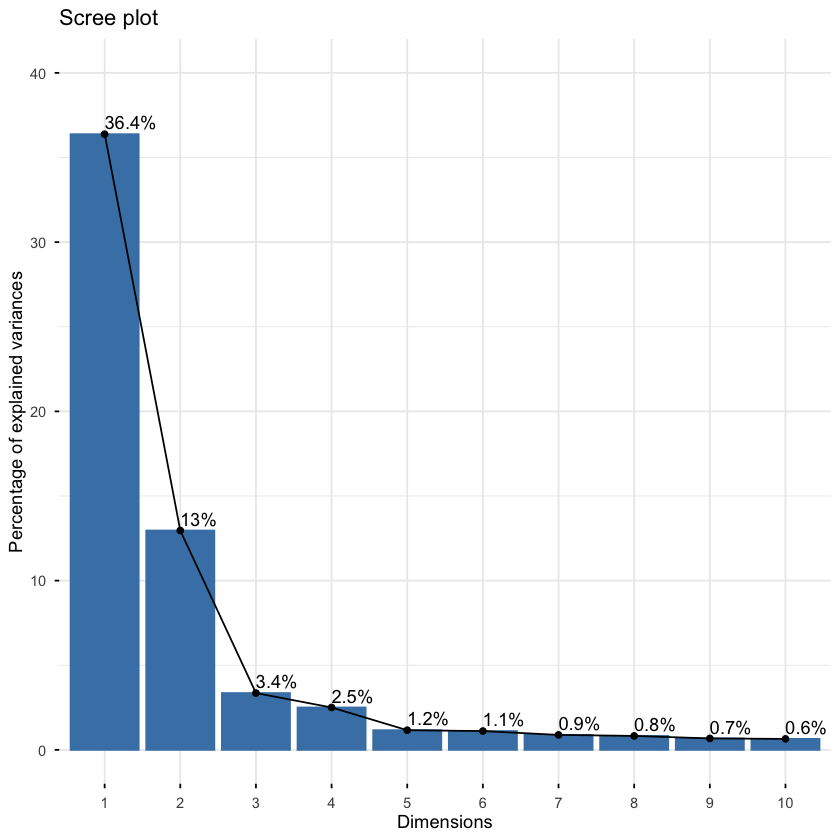

In [15]:
fviz_eig(pcavote, addlabels = TRUE, ylim = c(0, 40))

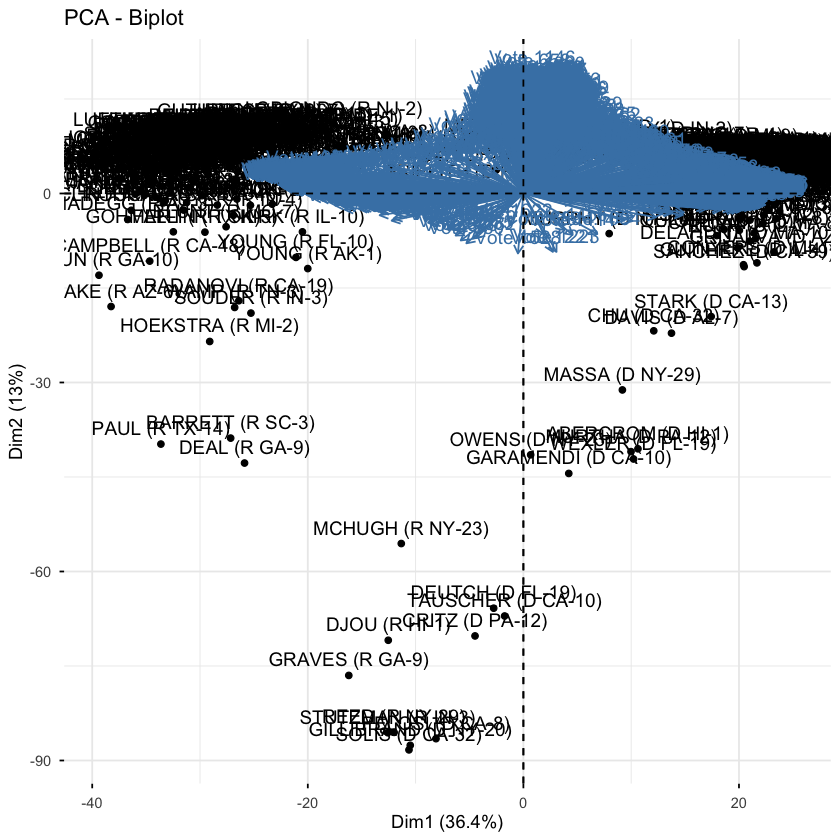

In [16]:
fviz_pca_biplot(pcavote)

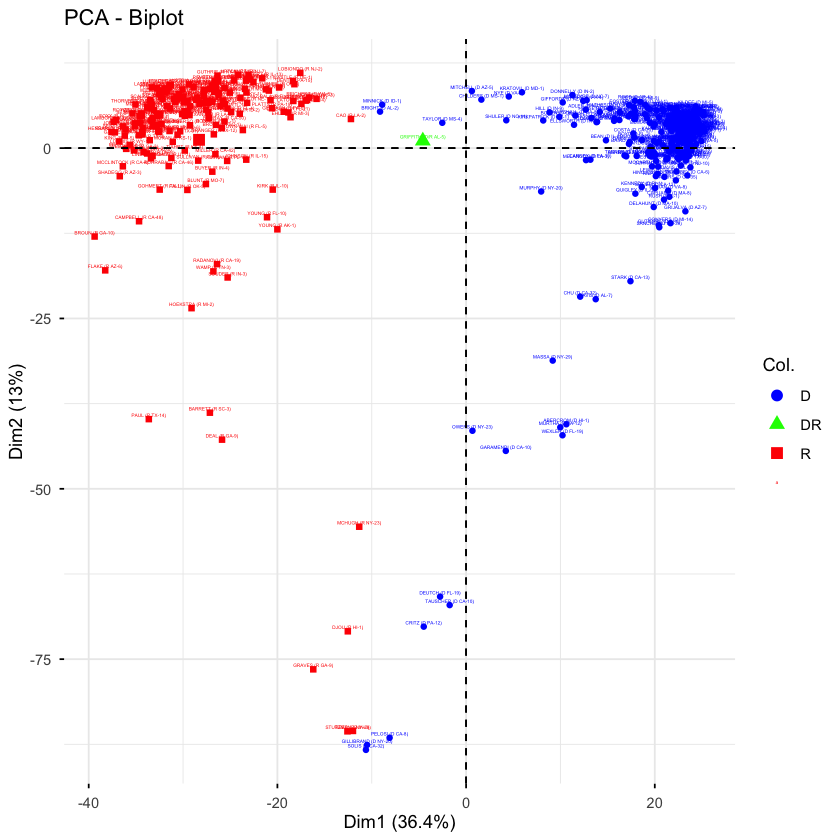

In [17]:
fviz_pca_biplot(pcavote, 
                col.ind = legis$party,
                palette = c("blue", "green", "red"),
                invisible ="var",
                repel=FALSE,
                labelsize = 1
                )

In [18]:
votepc <- predict(pcavote) #
votepc[order(votepc[,1])[1:5],1]

BROUN (R GA-10)     FLAKE (R AZ-6) HENSARLIN (R TX-5)   LAMBORN (R CO-5) 
         -39.37394          -38.25067          -37.58706          -37.37032 
   FRANKS (R AZ-2) 
         -37.22842

In [19]:
votepc[order(-votepc[,1])[1:5],1]

EDWARDS (D MD-4)    PRICE (D NC-4)   MATSUI (D CA-5) SCHAKOWS (D IL-9) 
         25.29151          25.15912          25.12481          24.98754 
  HIRONO (D HI-2) 
         24.98547

In [20]:
votepc[order(votepc[,2])[1:5],2]

SOLIS (D CA-32) GILLIBRAND (D NY-20)      PELOSI (D CA-8) 
           -88.31351            -87.58872            -86.53586 
   STUTZMAN (R IN-3)       REED (R NY-29) 
           -85.59217            -85.53636

In [21]:
votepc[order(-votepc[,2])[1:5],2]

LOBIONDO (R NJ-2)    UPTON (R MI-6)    LANCE (R NJ-7)  GUTHRIE (R KY-2) 
         11.04252          10.74400          10.74006          10.64870 
BIGGERT (R IL-13) 
         10.23859

In [22]:
loadings <- pcavote$rotation[,1:2]

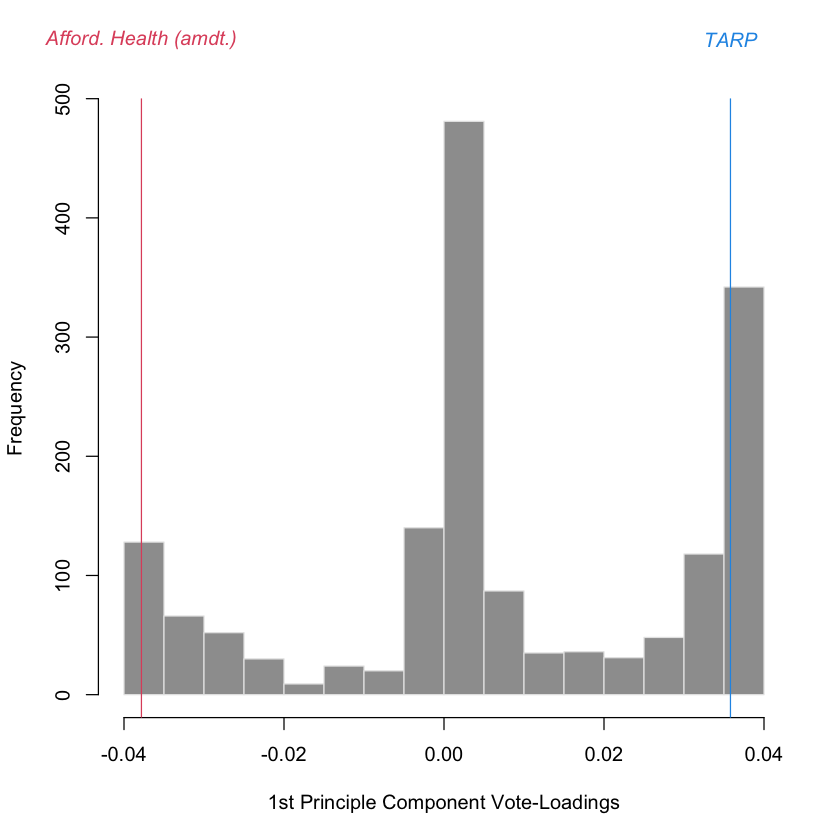

In [23]:
hist(loadings[,1], main="", xlab="1st Principle Component Vote-Loadings",
     col=8, border=grey(.9))
abline(v=loadings[884,1], col=2)
text(x=loadings[884,1], y=550, "Afford. Health (amdt.)", xpd=TRUE, col=2, font=3)
abline(v=loadings[25,1], col=4)
text(x=loadings[25,1], y=550, "TARP", xpd=TRUE, col=4, font=3)

In [24]:
loadings[order(abs(loadings[,2]), decreasing=TRUE)[1:5],2]

Vote.1146   Vote.658  Vote.1090  Vote.1104  Vote.1149 
0.05605862 0.05461947 0.05300806 0.05168382 0.05155729

In [25]:
sort(rowSums(votes==0), decreasing=TRUE)[1:5]

SOLIS (D CA-32) GILLIBRAND (D NY-20)       REED (R NY-29) 
                1628                 1619                 1562 
   STUTZMAN (R IN-3)      PELOSI (D CA-8) 
                1557                 1541

# Regresión por Componentes Principales (PCR)

Ahora que ya sabemos cómo ajustar modelos de factores, ¿para qué sirven?

- En algunos contextos, como el ejemplo de ciencias políticas, los factores tienen un significado claro y ayudan a entender sistemas complejos.
- Más comúnmente, sin embargo, los factores pueden no tener una interpretación clara.
- Aun así, pueden ser útiles como insumos en un sistema de regresión.
- De hecho, esta es una de las principales aplicaciones prácticas del PCA: ser la primera etapa en la Regresión por Componentes Principales (PCR).



La idea detrás de la PCR es simple:

- En lugar de ajustar un modelo $y \sim X $, 
- Se usan un conjunto reducido de componentes principales (PCs) como regresores.

Esto es útil por varias razones:

- El PCA reduce la dimensionalidad del problema, lo cual suele ser beneficioso.
- Los componentes principales son independientes, por lo tanto, no hay multicolinealidad y la regresión final es más fácil de ajustar.

## Algoritmo paso a paso de la PCR

El procedimiento es sencillo:

1. Aplicar PCA a las variables predictoras \( X \)
2. Extraer los primeros K componentes principales
3. Ajustar una regresión lineal de y sobre los componentes

### Limitaciones de la PCR

- La PCR se basa en los componentes principales de \( X \), que capturan las mayores fuentes de variación en los datos.
- Si la variable de interés \( y \) está relacionada con esas fuentes dominantes de variación, la PCR funcionará bien.
- Pero si \( y \) depende de una pequeña cantidad de variables específicas (una "aguja en un pajar"), la PCR podría no funcionar bien.
- En la práctica, es difícil saber de antemano qué escenario se tiene. Por eso, conviene comparar PCR con otras alternativas como LASSO directamente sobre los \( X \).

## ¿Cuántos componentes principales usar?

Cuando usamos PCA solo para reducir la dimensión, teníamos algunas reglas para elegir el número de componentes.

¿Deberíamos aplicar lo mismo aquí?

En la PCR el enfoque es un poco diferente:

- Se calculan \( min(n-1, p) \) componentes.
- Luego se hace validación cruzada (por ejemplo K-fold) agregando un PC a la vez.
- Se elige el modelo que minimiza el error cuadrático medio fuera de muestra (MSE).

Como los PCs están ordenados por varianza explicada y son independientes, este procedimiento suele funcionar mejor que seleccionar subconjuntos directamente sobre las variables originales.

### Estrategias híbridas con LASSO

- Una alternativa práctica: ajustar una regresión LASSO sobre todos los componentes principales.
- Este enfoque facilita la inclusión de información adicional.

Por ejemplo:

- Incluir tanto los PCs como las variables \( X \) originales en la matriz del modelo LASSO.
- Esto permite que el modelo aproveche tanto la estructura latente (los factores) como señales específicas de variables individuales relacionadas con \( y \).
- Esta estrategia híbrida soluciona la principal desventaja de la PCR: que sólo captura las principales fuentes de variación de \( X \).


# Texto como Datos: Ejemplos

## Regresión con Texto: Gentzkow and Shapiro

Vamos a usar los datos del estudio de Gentzkow y Shapiro [2010], que analiza cómo los periódicos ajustan su contenido según la orientación política de sus lectores.


<div >
<img src = "figures/gentzgow_shapiro.png" />
</div>

Cargamos los paquetes

In [26]:
require("pacman")
p_load("tidyverse","textir","wordcloud")

El conjunto de datos resume el primer año del 109º Congreso de los Estados Unidos (2005) e incluye todos los discursos de ese año de los miembros de la Cámara de Representantes y del Senado.

El texto ya está tokenizado en *bigrams* , después de eliminar las *stopwords* y aplicar un algoritmo de lematización (usando el *Porter stemmer*).

In [27]:
data("congress109", package = "textir")

La matriz `congress109Counts` contiene el número de veces que cada una de las 1000 frases más comunes fue utilizada en el 109º Congreso por cada uno de los 529 miembros del Congreso (Cámara y Senado). 

Es decir, cada documento corresponde a la transcripción combinada de todos los discursos de un solo orador.

Podemos inspeccionar los conteos de algunas frases específicas para dos oradores:

In [28]:
congress109Counts[c("Barack Obama","John Boehner"),995:999]

2 x 5 sparse Matrix of class "dgCMatrix"
             stem.cel natural.ga hurricane.katrina trade.agreement
Barack Obama        .          1                20               7
John Boehner        .          .                14               .
             appropriation.bil
Barack Obama                12
John Boehner                 .

Tambien tenemos información sobre  el partido que pertenecen el estado, la camara, y la proporcion de votos que obtuvo Bush en la eleccion presindecial en el distrito/estado de cada representante

In [29]:
congress109Ideology[c("Barack Obama","John Boehner"),1:5]

,name,party,state,chamber,repshare
,<chr>,<fct>,<fct>,<fct>,<dbl>
Barack Obama,Barack Obama,D,IL,S,0.4479136
John Boehner,John Boehner,R,OH,H,0.6456248


Vamos a tratar de predecir estos votos  a partir de como los congresistas hablan. La idea es que el lenguage apela a los votantes: 

In [30]:
as.matrix(congress109Counts[c("Tom Price","William Jefferson"),c("death.tax","estate.tax")])

,death.tax,estate.tax
Tom Price,28,0
William Jefferson,2,32


### Regresión LASSO

En una primera etapa, los autores buscan predecir la ideología del distrito a partir del lenguaje del congresista. Definen con $i = 1, \dots, n$ con $n = 529$ congresistas y $j = 1, \dots, p$ con $p = 1{,}000$ frases.




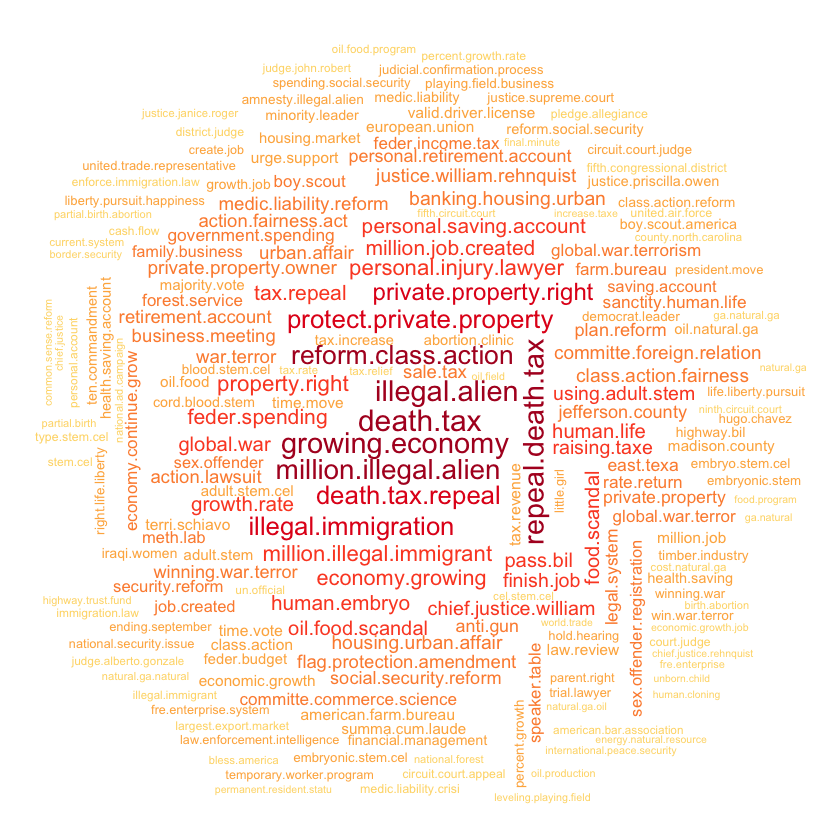

In [31]:
# Outcome
repshare <- congress109Ideology$repshare

# Veces que 
X1 <- as.matrix(congress109Counts)
words<-colnames(X1)

covariance<-apply(X1,2,function(x) cor(x,repshare))

                  

wordcloud(words = words,
          freq = covariance,
          min.freq = 0,
          scale = c(1.5, 0.1), 
          max.words=200, 
          random.order=FALSE, 
          colors=brewer.pal(8, "YlOrRd"))
          

Sin embargo, para ilustrar haremos la regresión sobre si utilizó la frase, ignorando el número de veces. Entonces definimos el indicador de uso de la frase $j$ por el congresista $i$ como:

$$D_{ij} = \mathbf{1}\{c_{ij} > 0\} \in \{0, 1\}$$

donde $c_{ij}$ es el número de veces que el congresista $i$ usó la frase $j$.


El modelo es:

$$\text{RepShare}_i = \alpha + \sum_{j=1}^{p} \beta_j D_{ij} + u_i$$

Como $p > n$, MCO no esta identificado y lo estimamos por LASSO:

$$(\hat{\alpha}, \hat{\boldsymbol{\beta}}) = \underset{\alpha,\, \boldsymbol{\beta}}{\arg\min}
\; \frac{1}{n} \sum_{i=1}^{n} \left(\text{RepShare}_i - \alpha - \sum_{j=1}^{p} \beta_j D_{ij}\right)^2
+ \lambda \sum_{j=1}^{p} |\beta_j|$$

con $\lambda$ seleccionado por validación cruzada. La penalización lleva a cero los coeficientes
de las frases sin poder predictivo, dejando solo las frases cuyo uso discrimina entre distritos
republicanos y demócratas.

In [32]:
# Predictores
X <- as(congress109Counts, "dMatrix")

La función `as(congress109Counts, "dMatrix")` convierte la matriz de conteos a formato de matriz dispersa (*sparse matrix*), que almacena únicamente los valores distintos de cero. Esto es esencial aquí porque la matriz de 529 congresistas × 1,000 frases está dominada por ceros (la mayoría de los congresistas no usan la mayoría de las frases).

Para estimar, vamos a usar `cv.gamlr` del paquete `gamlr`. Esto equivale a usar `train()` de `caret` con `method = "glmnet"` y validación cruzada. Estima el LASSO sobre un camino de valores de $\lambda$ y selecciona el óptimo automáticamente.

El argumento `X>0` binariza la matriz de conteos en el momento de la llamada, de modo que los regresores son indicadores de uso de cada frase, no los conteos crudos.

In [33]:
# lasso
lassoslant <- cv.gamlr(X>0, repshare)  

'as(<lgCMatrix>, "dgCMatrix")' is deprecated.
Use 'as(., "dMatrix")' instead.
See help("Deprecated") and help("Matrix-deprecated").



Extraemos los coeficientes del modelo LASSO excepto el intercepto (la primera fila es el intercepto, así que [-1,])

In [34]:
B <- coef(lassoslant, select = "min")[-1,]

In [35]:
top_rep <- tail(sort(round(B[B != 0], 4)), 10)

data.frame(
  Frase       = names(top_rep),
  Coeficiente = as.numeric(top_rep)
)

Frase,Coeficiente
<chr>,<dbl>
global.war,0.0112
raise.taxe,0.0117
pass.bil,0.0118
look.forward,0.0132
illegal.immigration,0.0144
private.property,0.0165
action.lawsuit,0.0175
troop.famili,0.0197
million.illegal.alien,0.0299


In [36]:
top_dem <- head(sort(round(B[B != 0], 4)), 10)

data.frame(
  Frase       = names(top_dem),
  Coeficiente = as.numeric(top_dem)
)

Frase,Coeficiente
<chr>,<dbl>
congressional.black.caucu,-0.0829
issue.facing.american,-0.0530
family.value,-0.0461
universal.health.care,-0.0410
minority.owned.business,-0.0335
civil.right,-0.0298
voter.registration,-0.0286
strong.opposition,-0.0259
congressional.hispanic.caucu,-0.0241
